Environment Setup:

*   Install Ultralytics
*   Import libraries

*   Verify YOLO11





In [1]:
!pip install ultralytics

from ultralytics import YOLO

model = YOLO('yolo11n.pt')

results = model('https://ultralytics.com/images/bus.jpg')

print("Ultralytics installed successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 79.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 8.2ms
Speed: 62.7ms preprocess, 8.2ms inference, 37.8ms postprocess per image at shape (1, 3, 640, 480)
Ultralytics installed successfully!


Dowload Dataset: Kaggle

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("snehilsanyal/construction-site-safety-image-dataset-roboflow")

print("Path to dataset files:", path)

100%|██████████| 206M/206M [00:10<00:00, 20.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/snehilsanyal/construction-site-safety-image-dataset-roboflow/versions/3


Explore Dataset:



*   Verify folder structure
*   Confirm training, validation, and testing folders

*  Verify images and labels are present






In [3]:
import os

print("Dataset path:", path)
print(os.listdir(path))

Dataset path: /root/.cache/kagglehub/datasets/snehilsanyal/construction-site-safety-image-dataset-roboflow/versions/3
['css-data', 'results_yolov8n_100e', 'source_files']


In [4]:
css_path = os.path.join(path, "css-data")

print(os.listdir(css_path))
print(os.listdir(os.path.join(css_path, "train")))
print(os.listdir(os.path.join(css_path, "valid")))

['train', 'test', 'README.roboflow.txt', 'valid', 'README.dataset.txt']
['images', 'labels']
['images', 'labels']


Sample Images to ensure images are clear to use

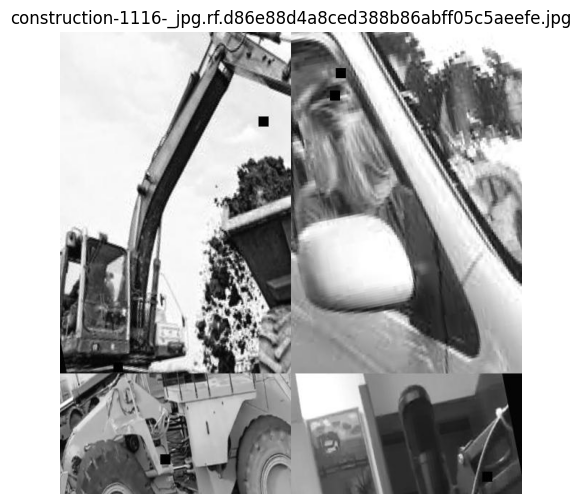

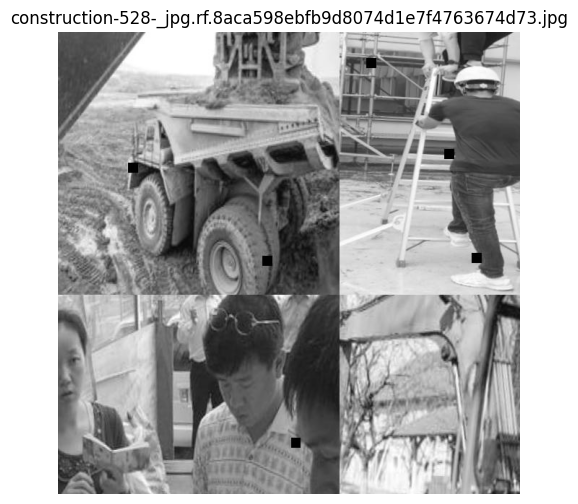

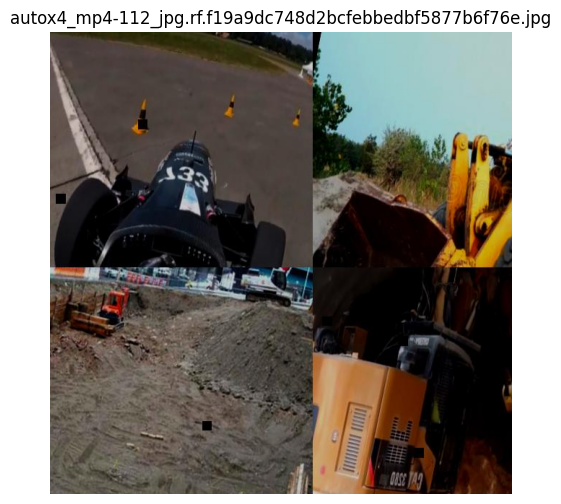

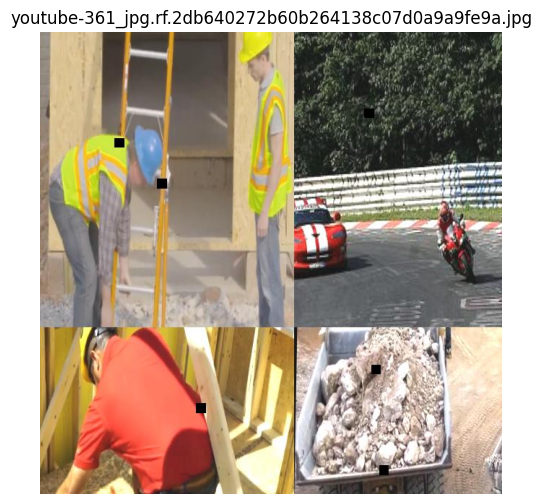

In [5]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

train_images_path = os.path.join(css_path, "train", "images")

image_files = [
    file for file in os.listdir(train_images_path)
    if file.lower().endswith((".jpg", ".jpeg", ".png"))
]

sample_files = random.sample(image_files, min(4, len(image_files)))

for file_name in sample_files:
    image_path = os.path.join(train_images_path, file_name)
    image = Image.open(image_path)

    plt.figure(figsize=(8, 6))
    plt.imshow(image)
    plt.title(file_name)
    plt.axis("off")
    plt.show()

In [6]:
for file_name in ["README.dataset.txt", "README.roboflow.txt"]:
    file_path = os.path.join(css_path, file_name)

    print(f"\n--- {file_name} ---")
    with open(file_path, "r") as file:
        print(file.read())


--- README.dataset.txt ---
# Construction Site Safety > YOLOv5s
https://universe.roboflow.com/roboflow-universe-projects/construction-site-safety

Provided by a Roboflow user
License: CC BY 4.0

videos from:
* https://www.youtube.com/watch?v=Dhxf5mm7g1g
* https://www.youtube.com/watch?v=rYv9JZ2XBW4

images cloned from:
* https://universe.roboflow.com/roboflow-universe-projects/personal-protective-equipment-combined-model/
* https://universe.roboflow.com/roboflow-universe-projects/people-and-ladders/
* https://universe.roboflow.com/roboflow-universe-projects/safety-vests/
* https://universe.roboflow.com/mohamed-sabek-6zmr6/excavators-cwlh0
* https://universe.roboflow.com/popular-benchmarks/mit-indoor-scene-recognition/ - null images
* https://universe.roboflow.com/mohamed-traore-2ekkp/people-detection-general
* https://universe.roboflow.com/labeler-projects/construction-madness/

--- README.roboflow.txt ---

Construction Site Safety - v28 YOLOv5s

This dataset was exported via roboflow

In [7]:
with open(os.path.join(css_path, "README.roboflow.txt"), "r") as f:
    text = f.read()

print(text)


Construction Site Safety - v28 YOLOv5s

This dataset was exported via roboflow.com on February 1, 2023 at 4:08 PM GMT

Roboflow is an end-to-end computer vision platform that helps you
* collaborate with your team on computer vision projects
* collect & organize images
* understand and search unstructured image data
* annotate, and create datasets
* export, train, and deploy computer vision models
* use active learning to improve your dataset over time

For state of the art Computer Vision training notebooks you can use with this dataset,
visit https://github.com/roboflow/notebooks

To find over 100k other datasets and pre-trained models, visit https://universe.roboflow.com

The dataset includes 2801 images.
Construction are annotated in YOLOv8 format.

The following pre-processing was applied to each image:
* Auto-orientation of pixel data (with EXIF-orientation stripping)
* Resize to 640x640 (Stretch)

The following augmentation was applied to create 5 versions of each source image:

In [8]:
yaml_content = f"""
path: {css_path}
train: train/images
val: valid/images
test: test/images

nc: 10

names:
  0: Hardhat
  1: Mask
  2: NO-Hardhat
  3: NO-Mask
  4: NO-Safety Vest
  5: Person
  6: Safety Cone
  7: Safety Vest
  8: machinery
  9: vehicle
"""

yaml_path = "/content/data.yaml"

with open(yaml_path, "w") as file:
    file.write(yaml_content)

print("Created:", yaml_path)

with open(yaml_path, "r") as file:
    print(file.read())

Created: /content/data.yaml

path: /root/.cache/kagglehub/datasets/snehilsanyal/construction-site-safety-image-dataset-roboflow/versions/3/css-data
train: train/images
val: valid/images
test: test/images

nc: 10

names:
  0: Hardhat
  1: Mask
  2: NO-Hardhat
  3: NO-Mask
  4: NO-Safety Vest
  5: Person
  6: Safety Cone
  7: Safety Vest
  8: machinery
  9: vehicle



Load pretrained Yolo11 Model and Run a short training test

In [9]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

results = model.train(
    data=yaml_path,
    epochs=10,
    imgsz=640,
    batch=16,
    name="shieldsight_test")

Ultralytics 8.4.112 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=shieldsight_test, nbs=64, nms=False, opset=

Validation of the test model

In [10]:
model = YOLO('runs/detect/shieldsight_test/weights/best.pt')
metrics = model.val()

print(f"mAP50:     {metrics.box.map50:.3f}")
print(f"mAP50-95:  {metrics.box.map:.3f}")
print(f"Precision: {metrics.box.mp:.3f}")
print(f"Recall:    {metrics.box.mr:.3f}")


Ultralytics 8.4.112 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,584,102 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1902.9±568.7 MB/s, size: 59.5 KB)
val: Scanning /root/.cache/kagglehub/datasets/snehilsanyal/construction-site-safety-image-dataset-roboflow/versions/3/css-data/valid/labels.cache... 114 images, 10 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 114/114 36.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 2.4it/s 3.4s
                   all        114        697        0.8       0.63        0.7      0.371
               Hardhat         42         79      0.946      0.747      0.811      0.465
                  Mask         19         21      0.912       0.81      0.819      0.424
            NO-Hardhat         37         69      0.718      0.464      0.562      0.249
               NO-Mask         44      

Remap classes so that only 5 needed classes appear

* 0 → 0  Hardhat
* 2 → 1  NO-Hardhat
* 4 → 2  NO-Safety Vest
* 5 → 3  Person
* 7 → 4  Safety Vest





In [11]:
import os
import shutil

# Original dataset
source_root = css_path

# New writable filtered dataset
filtered_root = "/content/shieldsight_5class"

# Original class ID -> new class ID
class_mapping = {
    0: 0,  # Hardhat
    2: 1,  # NO-Hardhat
    4: 2,  # NO-Safety Vest
    5: 3,  # Person
    7: 4   # Safety Vest
}

image_extensions = [".jpg", ".jpeg", ".png"]

# Start fresh if the folder already exists
if os.path.exists(filtered_root):
    shutil.rmtree(filtered_root)

for split in ["train", "valid", "test"]:
    source_images = os.path.join(source_root, split, "images")
    source_labels = os.path.join(source_root, split, "labels")

    output_images = os.path.join(filtered_root, split, "images")
    output_labels = os.path.join(filtered_root, split, "labels")

    os.makedirs(output_images, exist_ok=True)
    os.makedirs(output_labels, exist_ok=True)

    kept_images = 0
    kept_boxes = 0

    for label_name in os.listdir(source_labels):
        if not label_name.endswith(".txt"):
            continue

        source_label_path = os.path.join(source_labels, label_name)
        new_lines = []

        with open(source_label_path, "r") as file:
            for line in file:
                parts = line.strip().split()

                if len(parts) != 5:
                    continue

                original_class = int(parts[0])

                if original_class in class_mapping:
                    parts[0] = str(class_mapping[original_class])
                    new_lines.append(" ".join(parts))
                    kept_boxes += 1

        # Only copy images that still have at least one selected annotation
        if new_lines:
            output_label_path = os.path.join(output_labels, label_name)

            with open(output_label_path, "w") as file:
                file.write("\n".join(new_lines) + "\n")

            image_base = os.path.splitext(label_name)[0]

            for extension in image_extensions:
                possible_image = os.path.join(
                    source_images,
                    image_base + extension
                )

                if os.path.exists(possible_image):
                    shutil.copy2(possible_image, output_images)
                    kept_images += 1
                    break

    print(
        f"{split}: {kept_images} images and "
        f"{kept_boxes} selected boxes"
    )

train: 2535 images and 21989 selected boxes
valid: 84 images and 461 selected boxes
test: 60 images and 476 selected boxes


New 5 case Yaml file

In [12]:
five_class_yaml = f"""
path: {filtered_root}
train: train/images
val: valid/images
test: test/images

nc: 5

names:
  0: Hardhat
  1: NO-Hardhat
  2: NO-Safety Vest
  3: Person
  4: Safety Vest
"""

five_class_yaml_path = "/content/shieldsight_5class.yaml"

with open(five_class_yaml_path, "w") as file:
    file.write(five_class_yaml)

print("Created:", five_class_yaml_path)

with open(five_class_yaml_path, "r") as file:
    print(file.read())

Created: /content/shieldsight_5class.yaml

path: /content/shieldsight_5class
train: train/images
val: valid/images
test: test/images

nc: 5

names:
  0: Hardhat
  1: NO-Hardhat
  2: NO-Safety Vest
  3: Person
  4: Safety Vest



In [13]:
for split in ["train", "valid", "test"]:
    image_dir = os.path.join(filtered_root, split, "images")
    label_dir = os.path.join(filtered_root, split, "labels")

    print(
        split,
        "images:", len(os.listdir(image_dir)),
        "labels:", len(os.listdir(label_dir))
    )

train images: 2535 labels: 2535
valid images: 84 labels: 84
test images: 60 labels: 60


In [14]:
from ultralytics import YOLO

model_5class = YOLO("yolo11n.pt")

results_5class_test = model_5class.train(
    data=five_class_yaml_path,
    epochs=5,
    imgsz=640,
    batch=16,
    device=0,
    name="shieldsight_5class_test"
)

Ultralytics 8.4.112 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/shieldsight_5class.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=shieldsight_5class_test, nbs=

Training Model for 5 classes only

In [15]:
from ultralytics import YOLO

final_model = YOLO("yolo11n.pt")

final_results = final_model.train(
    data=five_class_yaml_path,
    epochs=50,
    imgsz=640,
    batch=16,
    patience=10,
    name="shieldsight_5class_final"
)

Ultralytics 8.4.112 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/shieldsight_5class.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=shieldsight_5class_final, nbs

In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
from ultralytics import YOLO

final_model = YOLO(
    "/content/runs/detect/shieldsight_5class_final/weights/best.pt"
)

final_metrics = final_model.val(data=five_class_yaml_path)

print(f"mAP50: {final_metrics.box.map50:.3f}")
print(f"mAP50-95: {final_metrics.box.map:.3f}")
print(f"Precision: {final_metrics.box.mp:.3f}")
print(f"Recall: {final_metrics.box.mr:.3f}")

Ultralytics 8.4.112 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,583,127 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2144.9±899.3 MB/s, size: 60.5 KB)
val: Scanning /content/shieldsight_5class/valid/labels.cache... 84 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 84/84 29.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.9it/s 3.1s
                   all         84        461      0.888      0.705      0.788      0.473
               Hardhat         42         79      0.893      0.739      0.861       0.53
            NO-Hardhat         37         69      0.877      0.551      0.634      0.335
        NO-Safety Vest         56        106      0.875      0.663      0.751      0.458
                Person         84        166      0.843      0.741      0.826      0.509
           Safety Vest         28      

In [21]:
import os
os.makedirs("/content/drive/MyDrive/ShieldSight", exist_ok=True)

In [22]:
import shutil

source = "/content/runs/detect/shieldsight_5class_final/weights/best.pt"
destination = "/content/drive/MyDrive/ShieldSight/best.pt"

shutil.copy(source, destination)

print("Model saved to Google Drive!")

Model saved to Google Drive!
